 ## Install Scikit-learn

In [5]:
pip install scikit-learn

# PART 1: DATA PREPROCESSING (30 minutes)
## Task 1.1: Load Libraries and Data (5 min)

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


## Load the data (customer_data.csv):

In [7]:
# Load data
df = pd.read_csv('customer_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 1.2: Handle Missing Values (10 min)

In [8]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())
# Convert TotalCharges to numeric (it may have spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Verify no missing values remain
print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values after cleaning: 0


## Task 1.3: Encode Categorical Variables (15 min)
### Convert categorical text into numbers:

In [9]:
# List of columns to encode
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract',
'PaperlessBilling', 'PaymentMethod']
# Create dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f'Original columns: {df.shape[1]}')
print(f'After encoding: {df_encoded.shape[1]}')
print(f'New columns created: {df_encoded.shape[1] - df.shape[1]}')


Original columns: 21
After encoding: 32
New columns created: 11


### Encode the target variable:

In [10]:
# Convert Churn to binary (Yes=1, No=0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
# Verify encoding
print('Churn distribution:')
print(df_encoded['Churn'].value_counts())

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


# PART 2: PREPARE DATA FOR TRAINING (10 minutes)
## Task 2.1: Separate Features and Target (5 min)

In [11]:
# Drop non-predictive columns
df_model = df_encoded.drop(['customerID'], axis=1)
# Separate features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts(normalize=True))

Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


## Task 2.2: Split into Train and Test Sets (5 min)

In [12]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nChurn distribution in training set:')
print(y_train.value_counts(normalize=True))

Training set: 5634 samples
Test set: 1409 samples

Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


# PART 3: MODEL 1 - LOGISTIC REGRESSION (15 minutes)
## Task 3.1: Train Logistic Regression (8 min)

In [13]:
# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
# Make predictions
y_pred_lr = lr_model.predict(X_test)
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')

Logistic Regression Accuracy: 0.8041


## Task 3.2: Evaluate Model Performance (7 min)
### Get detailed metrics:

In [14]:
# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred_lr))
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print('\nConfusion Matrix:')
print(cm_lr)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Confusion Matrix:
[[926 109]
 [167 207]]


### Visualize confusion matrix:

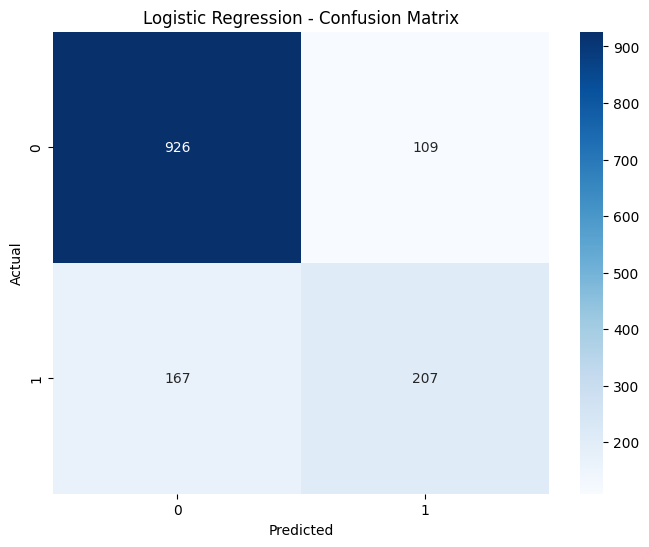

In [15]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

# PART 4: MODEL 2 - DECISION TREE (10 minutes)
## Task 4.1: Train Decision Tree (5 min)

In [16]:
# Create and train decision tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
# Make predictions
y_pred_dt = dt_model.predict(X_test)
# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f}')

Decision Tree Accuracy: 0.7942


## Task 4.2: Feature Importance (5 min)

Top 10 Most Important Features:
                                feature  importance
1                                tenure    0.421435
10          InternetService_Fiber optic    0.357542
3                          TotalCharges    0.047129
28       PaymentMethod_Electronic check    0.036761
9                     MultipleLines_Yes    0.023630
12   OnlineSecurity_No internet service    0.020669
25                    Contract_Two year    0.019599
22  StreamingMovies_No internet service    0.017379
2                        MonthlyCharges    0.016847
19                      TechSupport_Yes    0.012988


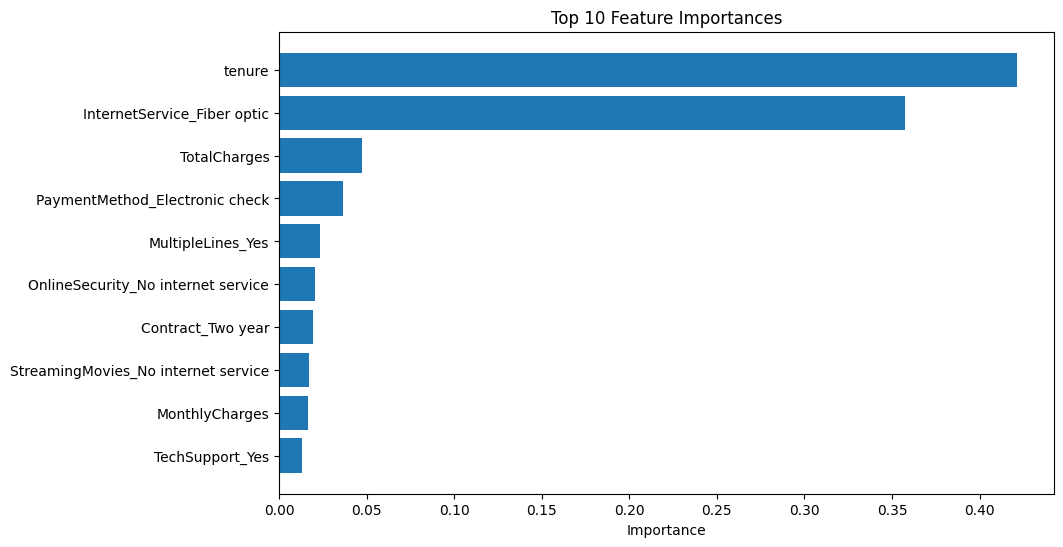

In [17]:
# Get feature importance
feature_importance = pd.DataFrame({
'feature': X_train.columns,
'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)
# Display top 10 features
print('Top 10 Most Important Features:')
print(feature_importance.head(10))
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10),
feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()


# PART 5: MODEL 3 - RANDOM FOREST (10 minutes)
## Task 5.1: Train Random Forest (5 min)

In [18]:
# Create and train random forest
rf_model = RandomForestClassifier(
n_estimators=100, # Number of trees
random_state=42,
max_depth=10
)
rf_model.fit(X_train, y_train)
# Make predictions
y_pred_rf = rf_model.predict(X_test)
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

Random Forest Accuracy: 0.8070


## Task 5.2: Evaluate Random Forest (5 min)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



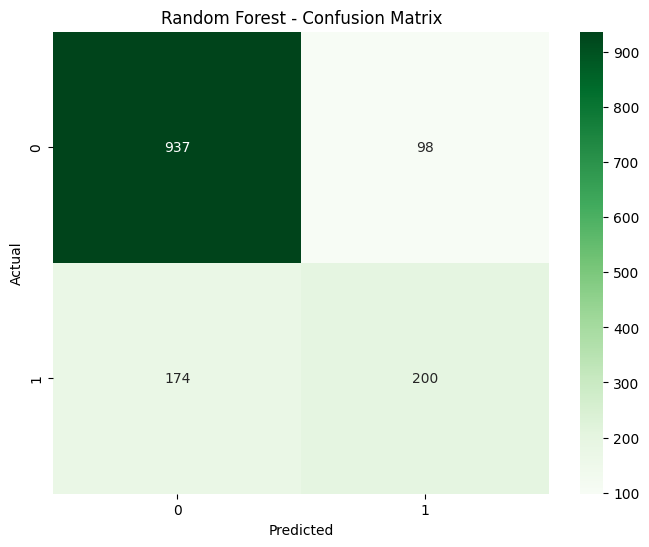

In [19]:
# Classification report
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
plt.title('Random Forest - Confusion Matrix')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



# PART 6: COMPARE ALL MODELS (10 minutes)
## Task 6.1: Create Comparison Table (5 min)

In [20]:
# Create comparison dataframe
results = pd.DataFrame({
'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy]
})
# Sort by accuracy
results = results.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(results)
# Find best model
best_model = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']
print(f'\nBest Model: {best_model} with {best_accuracy:.4f} accuracy')

Model Comparison:
                 Model  Accuracy
2        Random Forest  0.806955
0  Logistic Regression  0.804116
1        Decision Tree  0.794180

Best Model: Random Forest with 0.8070 accuracy


## Task 6.2: Visualize Comparison (5 min)

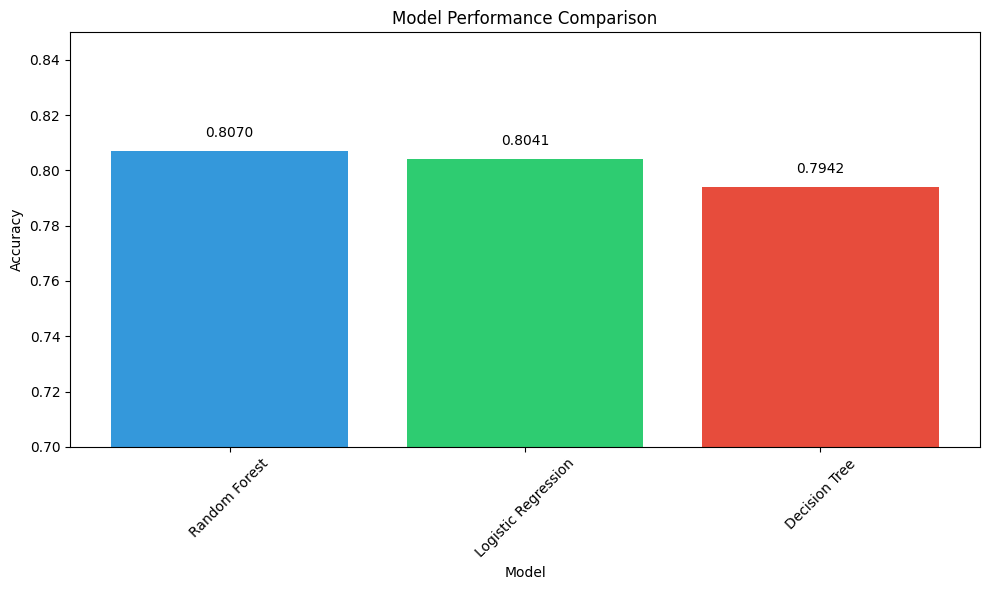

In [21]:
# Plot model comparison
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Accuracy'], color=['#3498db', '#2ecc71',
'#e74c3c'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0.7, 0.85) # Adjust based on your results
plt.xticks(rotation=45)
# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')
    plt.tight_layout()
plt.show()


# PART 7: FEATURE ENGINEERING (BONUS - 15 minutes)
## Task 7.1: Create New Features

In [22]:
# Go back to the original dataframe before encoding
df_new = df.copy()
# Feature 1: Total Revenue (tenure * monthly charges)
df_new['TotalRevenue'] = df_new['tenure'] * df_new['MonthlyCharges']
# Feature 2: Count total services
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies']
df_new['TotalServices'] = (df_new[service_cols] != 'No').sum(axis=1)
# Feature 3: Tenure groups
df_new['TenureGroup'] = pd.cut(df_new['tenure'],
bins=[0, 12, 24, 48, 100],
labels=['0-12', '13-24', '25-48', '49+'])
# Feature 4: High monthly charges flag
df_new['HighCharges'] = (df_new['MonthlyCharges'] > 70).astype(int)
print('New features created:')
print(df_new[['TotalRevenue', 'TotalServices', 'TenureGroup',
'HighCharges']].head())

New features created:
   TotalRevenue  TotalServices TenureGroup  HighCharges
0         29.85              2        0-12            0
1       1936.30              4       25-48            0
2        107.70              4        0-12            0
3       1903.50              4       25-48            0
4        141.40              2        0-12            1


## Task 7.2: Retrain Best Model with New Features

In [30]:
# ----- Separate target BEFORE encoding -----
y_new = df_new['Churn'].map({'Yes': 1, 'No': 0})

# Prepare feature dataframe
X_new = df_new.drop(['customerID', 'Churn'], axis=1)

# ----- Encode categorical features only -----
X_new = pd.get_dummies(X_new, drop_first=True)

# ----- Train-Test Split (use stratify for balanced churn ratio) -----
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# ----- Train Random Forest -----
rf_new = RandomForestClassifier(
    n_estimators=300,      # more trees improves stability
    max_depth=12,
    max_features='sqrt',
    random_state=42
)

rf_new.fit(X_train_new, y_train_new)

# ----- Evaluate -----
y_pred_new = rf_new.predict(X_test_new)
new_accuracy = accuracy_score(y_test_new, y_pred_new)

print(f'Original Random Forest Accuracy: {rf_accuracy:.4f}')
print(f'With New Features Accuracy: {new_accuracy:.4f}')
print(f'Improvement: {(new_accuracy - rf_accuracy):.4f}')


Original Random Forest Accuracy: 0.8070
With New Features Accuracy: 0.7921
Improvement: -0.0149


## Summary and Conclusions

### Models Trained
- **Logistic Regression:** 0.804116  
- **Decision Tree:** 0.794180  
- **Random Forest:** 0.806955  

### Best Model
**Random Forest** achieved the best performance with **0.806955 accuracy**.



### Key Findings

- **Most Important Features:**
  1. `tenure`
  2. `InternetService_Fiber optic`
  3. `TotalCharges`

- **Feature Engineering Impact:**  
  Additional engineered features were tested; however, they did **not improve the model accuracy**, reducing it slightly from **0.8070 to 0.7921**. This indicates that the original dataset already captures most of the predictive patterns for customer churn.

- **Challenges Faced:**
  - Ensuring the **dataset was loaded before feature engineering** to avoid empty DataFrames.
  - Fixing **variable naming confusion** (`df_new`, `df_encoded`, etc.) to prevent overwriting data.
  - Resolving **KeyError issues for `Churn` and `customerID`** caused by incorrect encoding order.
  - Handling **missing values and datatype issues** in `TotalCharges`.
  - Ensuring the **target variable (`Churn`) was encoded before applying `get_dummies()`**.



### Next Steps

- **Week 3:** Perform **hyperparameter tuning** to improve Random Forest performance.
- Explore **additional feature interactions and combinations**.
- Investigate **class imbalance handling techniques** (e.g., SMOTE, class weighting).
- Analyze **feature importance further** to refine the model.



*My Further Effort to Improve Random Forest Classifier's Accuracy*

In [32]:

# Work on engineered dataframe
df_model = df_new.copy()

# Convert TotalCharges safely (important for this dataset)
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(0)

# Encode target variable
y = df_model['Churn'].map({'Yes':1, 'No':0})

# Prepare features
X = df_model.drop(['customerID','Churn'], axis=1)

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy,4))

Random Forest Accuracy: 0.8034


In [33]:
# Convert TotalCharges safely
df_new['TotalCharges'] = pd.to_numeric(df_new['TotalCharges'], errors='coerce')
df_new['TotalCharges'] = df_new['TotalCharges'].fillna(0)

# Target
y = df_new['Churn'].map({'Yes':1,'No':0})

# Features
X = df_new.drop(['customerID','Churn'], axis=1)

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y
)

# Improved Random Forest
rf = RandomForestClassifier(
n_estimators=500,
max_depth=15,
min_samples_split=4,
min_samples_leaf=2,
max_features='sqrt',
random_state=42
)

rf.fit(X_train,y_train)

# Predict
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("Improved Random Forest Accuracy:",round(accuracy,4))

Improved Random Forest Accuracy: 0.8006


In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -----------------------------
# 1. Copy dataset
# -----------------------------
df_new = df.copy()

# Convert TotalCharges safely
df_new['TotalCharges'] = pd.to_numeric(df_new['TotalCharges'], errors='coerce')
df_new['TotalCharges'] = df_new['TotalCharges'].fillna(0)

# -----------------------------
# 2. Feature Engineering
# -----------------------------

# Total Revenue
df_new['TotalRevenue'] = df_new['tenure'] * df_new['MonthlyCharges']

# Total Services
service_cols = [
'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

df_new['TotalServices'] = (df_new[service_cols] == 'Yes').sum(axis=1)

# Tenure Groups
df_new['TenureGroup'] = pd.cut(
    df_new['tenure'],
    bins=[0,12,24,48,100],
    labels=['0-12','13-24','25-48','49+']
)

# High Charges Flag
df_new['HighCharges'] = (
    df_new['MonthlyCharges'] > df_new['MonthlyCharges'].median()
).astype(int)

# Avg Revenue Per Month
df_new['AvgRevenuePerMonth'] = df_new['TotalCharges'] / (df_new['tenure'] + 1)

# Charge Per Service
df_new['ChargePerService'] = df_new['MonthlyCharges'] / (df_new['TotalServices'] + 1)

# Loyal Customer
df_new['LoyalCustomer'] = (df_new['tenure'] > 48).astype(int)

# Fiber Optic User
df_new['FiberOpticUser'] = (df_new['InternetService'] == 'Fiber optic').astype(int)

# Contract Score
df_new['ContractScore'] = df_new['Contract'].map({
    'Month-to-month':0,
    'One year':1,
    'Two year':2
})

# Risky Payment
df_new['RiskyPayment'] = df_new['PaymentMethod'].isin(
    ['Electronic check','Mailed check']
).astype(int)

# Protection Services
protection_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']

df_new[protection_cols] = df_new[protection_cols].replace({
    'Yes':1,'No':0,'No internet service':0
})

df_new['ProtectionServices'] = df_new[protection_cols].sum(axis=1)

# Streaming Services
stream_cols = ['StreamingTV','StreamingMovies']

df_new[stream_cols] = df_new[stream_cols].replace({
    'Yes':1,'No':0,'No internet service':0
})

df_new['StreamingServices'] = df_new[stream_cols].sum(axis=1)

print("Feature Engineering Completed")

# -----------------------------
# 3. Prepare Model Data
# -----------------------------

# Target
y = df_new['Churn'].map({'Yes':1,'No':0})

# Features
X = df_new.drop(['customerID','Churn'], axis=1)

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# -----------------------------
# 4. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 5. Train Random Forest
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train, y_train)

# -----------------------------
# 6. Evaluate Model
# -----------------------------
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy,4))

Feature Engineering Completed
Random Forest Accuracy: 0.7913
